Max Nilsson & Sophie Cook

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [81]:
country_names = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CY': 'Cyprus',
    'CZ': 'Czechia', 'DE': 'Germany', 'DK': 'Denmark', 'EE': 'Estonia',
    'EL': 'Greece', 'ES': 'Spain', 'FI': 'Finland', 'FR': 'France',
    'HR': 'Croatia', 'HU': 'Hungary', 'IE': 'Ireland', 'IS': 'Iceland',
    'IT': 'Italy', 'LI': 'Liechtenstein', 'LT': 'Lithuania', 'LU': 'Luxembourg',
    'LV': 'Latvia', 'MT': 'Malta', 'NL': 'Netherlands', 'NO': 'Norway',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SE': 'Sweden',
    'SI': 'Slovenia', 'SK': 'Slovakia'
}

df_cases = raw data
df_cases_filtered_20to22 = data with correct dates
df_cases_clean = clean data

In [82]:
df_cases_original = pd.read_csv('1.COVID-19_daily_number_of_new_cases_and_deaths.csv')
df_vax_original = pd.read_csv('2.COVID-19_vaccination.csv')
df_hosp_original = pd.read_csv('3.COVID-19_hospital_and_ICU_admission_rates.csv')

df_cases = df_cases_original.copy()
df_vax = df_vax_original.copy()
df_hosp = df_hosp_original.copy()
# creating datetime objects and filtering for 2020-2022
df_cases['dateRep'] = pd.to_datetime(df_cases['dateRep'], format='%d/%m/%Y')
# Filter the cases dataset to include only data from 2020 to 2022
df_cases_clean = df_cases[(df_cases['dateRep'].dt.year >= 2020) & (df_cases['dateRep'].dt.year <= 2022)].copy()

In [83]:
display(df_cases.head())

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2020,continentExp
0,2022-10-23,23,10,2022,3557.0,0.0,Austria,AT,AUT,8901064,Europe
1,2022-10-22,22,10,2022,5494.0,4.0,Austria,AT,AUT,8901064,Europe
2,2022-10-21,21,10,2022,7776.0,4.0,Austria,AT,AUT,8901064,Europe
3,2022-10-20,20,10,2022,8221.0,6.0,Austria,AT,AUT,8901064,Europe
4,2022-10-19,19,10,2022,10007.0,8.0,Austria,AT,AUT,8901064,Europe


Preprocessing/ datacleaning



--- Datamängdens storlek (Rader, Kolumner) ---
Cases Data: (28729, 11)
Vaccine Data: (681330, 18)
Hospital Data: (25100, 7)

--- Saknade värden i Cases Data (Topp 5) ---
deaths     292
cases       93
dateRep      0
day          0
month        0
dtype: int64 

--- Datatyper i Cases Data ---
dateRep                    datetime64[us]
day                                 int64
month                               int64
year                                int64
cases                             float64
deaths                            float64
countriesAndTerritories               str
geoId                                 str
countryterritoryCode                  str
popData2020                         int64
continentExp                          str
dtype: object 



,cases,deaths,popData2020
count,28636.000000,28437.000000,2.872900e+04
mean,6088.425129,40.866160,1.534803e+07
std,21455.994469,128.729388,2.142396e+07
min,-348846.000000,-217.000000,3.874700e+04
25%,111.000000,0.000000,2.095861e+06
50%,705.000000,5.000000,6.951482e+06
75%,3483.250000,31.000000,1.152244e+07
max,501635.000000,13743.000000,8.316671e+07


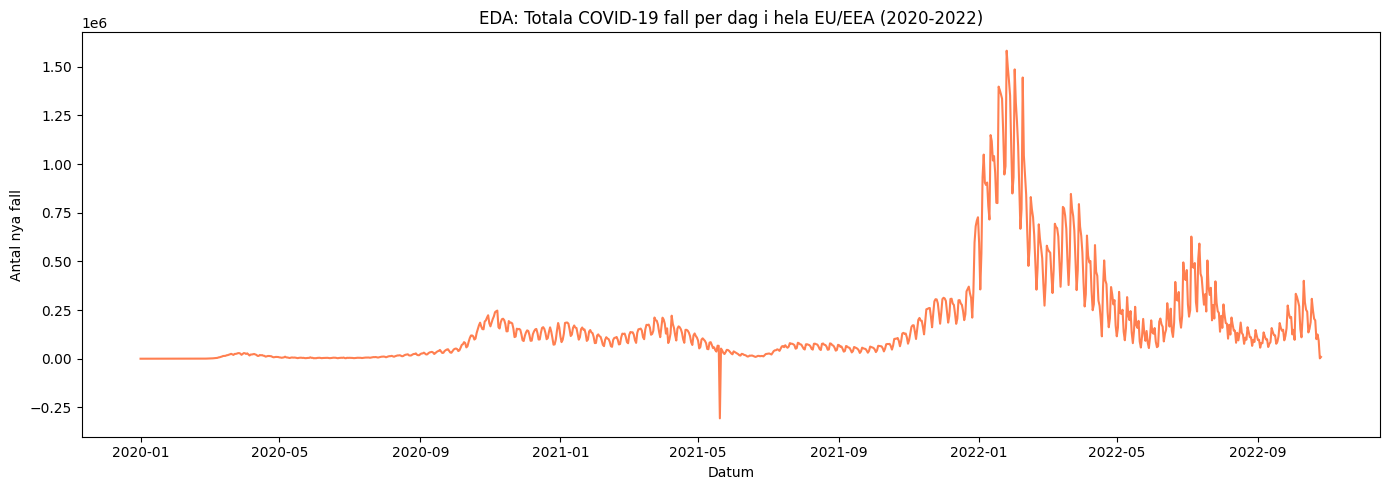

In [84]:
# chek data size
print("--- Datamängdens storlek (Rader, Kolumner) ---")
print(f"Cases Data: {df_cases.shape}")
print(f"Vaccine Data: {df_vax.shape}")
print(f"Hospital Data: {df_hosp.shape}\n")

# find missing values
print("--- Saknade värden i Cases Data (Topp 5) ---")
print(df_cases.isna().sum().nlargest(5), "\n")

# datatypes
print("--- Datatyper i Cases Data ---")
print(df_cases.dtypes, "\n")

# statistics for cases, deaths, and population
display(df_cases[['cases', 'deaths', 'popData2020']].describe())

#plotting
plt.figure(figsize=(14, 5))
global_trend = df_cases.groupby('dateRep')['cases'].sum().reset_index()

sns.lineplot(data=global_trend, x='dateRep', y='cases', color='coral')
plt.title('EDA: Totala COVID-19 fall per dag i hela EU/EEA (2020-2022)')
plt.ylabel('Antal nya fall')
plt.xlabel('Datum')
plt.tight_layout()
plt.show()

In [85]:
#check for duplicates
print(f"Duplicate rows in cases dataset: {df_cases.duplicated().sum()}")
#check for negative values in cases
print(f"Negative values in cases dataset: {df_cases_clean[df_cases_clean['cases'] < 0].shape[0]}")
print(f"Rows with negative deaths: {df_cases_clean[df_cases_clean['deaths'] < 0].shape[0]}")

Duplicate rows in cases dataset: 0
Negative values in cases dataset: 14
Rows with negative deaths: 17


In [86]:
#check for duplicates for all datasets
print(f"Duplicate rows in cases dataset: {df_cases.duplicated().sum()}")
print(f"Duplicate rows in vaccine dataset: {df_vax.duplicated().sum()}")
print(f"Duplicate rows in hospital dataset: {df_hosp.duplicated().sum()}")

#check for negative values
print(f"Negative values in cases dataset: {df_cases_clean[df_cases_clean['cases'] < 0].shape[0]}")
print(f"Rows with negative deaths: {df_cases_clean[df_cases_clean['deaths'] < 0].shape[0]}")
# 

Duplicate rows in cases dataset: 0
Duplicate rows in vaccine dataset: 0
Duplicate rows in hospital dataset: 0
Negative values in cases dataset: 14
Rows with negative deaths: 17


Datacleaning

In [87]:
# aplied to all datasets
df_cases = df_cases.drop_duplicates()
df_vax = df_vax.drop_duplicates()
df_hosp = df_hosp.drop_duplicates()

print("Dubbletter borttagna och datatvätt påbörjad...")

#CLEANING DATASET 1: Cases & Deaths
df_cases_clean = df_cases.dropna(subset=['cases', 'deaths', 'popData2020']).copy()
df_cases_clean = df_cases_clean[(df_cases_clean['cases'] >= 0) & (df_cases_clean['deaths'] >= 0)]

# CLEANING DATASET 2: Vaccination
df_vax['Population'] = pd.to_numeric(df_vax['Population'], errors='coerce')
df_vax['FirstDose'] = pd.to_numeric(df_vax['FirstDose'], errors='coerce')
df_vax['SecondDose'] = pd.to_numeric(df_vax['SecondDose'], errors='coerce')
df_vax['FirstDoseRefused'] = pd.to_numeric(df_vax['FirstDoseRefused'], errors='coerce')

df_vax_clean = df_vax.dropna(subset=['Population', 'TargetGroup']).copy()
df_vax_clean = df_vax_clean[df_vax_clean['TargetGroup'] != 'ALL']

# CLEANING DATASET 3: Hospital & ICU
df_hosp_clean = df_hosp.dropna(subset=['value']).copy()
df_hosp_clean['value'] = pd.to_numeric(df_hosp_clean['value'], errors='coerce').fillna(0)
# using string matching to filter for hospital-related indicators
df_hosp_clean = df_hosp_clean[df_hosp_clean['indicator'].str.contains('hospital', case=False, na=False)]

print("All data är nu tvättad")

Dubbletter borttagna och datatvätt påbörjad...
All data är nu tvättad


In [88]:
print(f"rows with negative cases: {(df_cases_clean['cases'] < 0).sum()}")
print(f"rows with negative deaths: {(df_cases_clean['deaths'] < 0).sum()}")

rows with negative cases: 0
rows with negative deaths: 0


Q1:

Top 10 countries with the most absolute number of cases:
1. France: 36952159
2. Germany: 35287690
3. Italy: 23359251
4. Spain: 13564823
5. Netherlands: 8494705
6. Poland: 6189562
7. Portugal: 5514482
8. Austria: 5402162
9. Greece: 5138059
10. Belgium: 4597870
Top 10 countries based on total cases per 100 000 people (2020-2022):
1. Austria: 60691
2. France: 54890
3. Portugal: 53559
4. Netherlands: 48798
5. Greece: 47936
6. Germany: 42430
7. Belgium: 39903
8. Italy: 39166
9. Spain: 28658
10. Poland: 16306


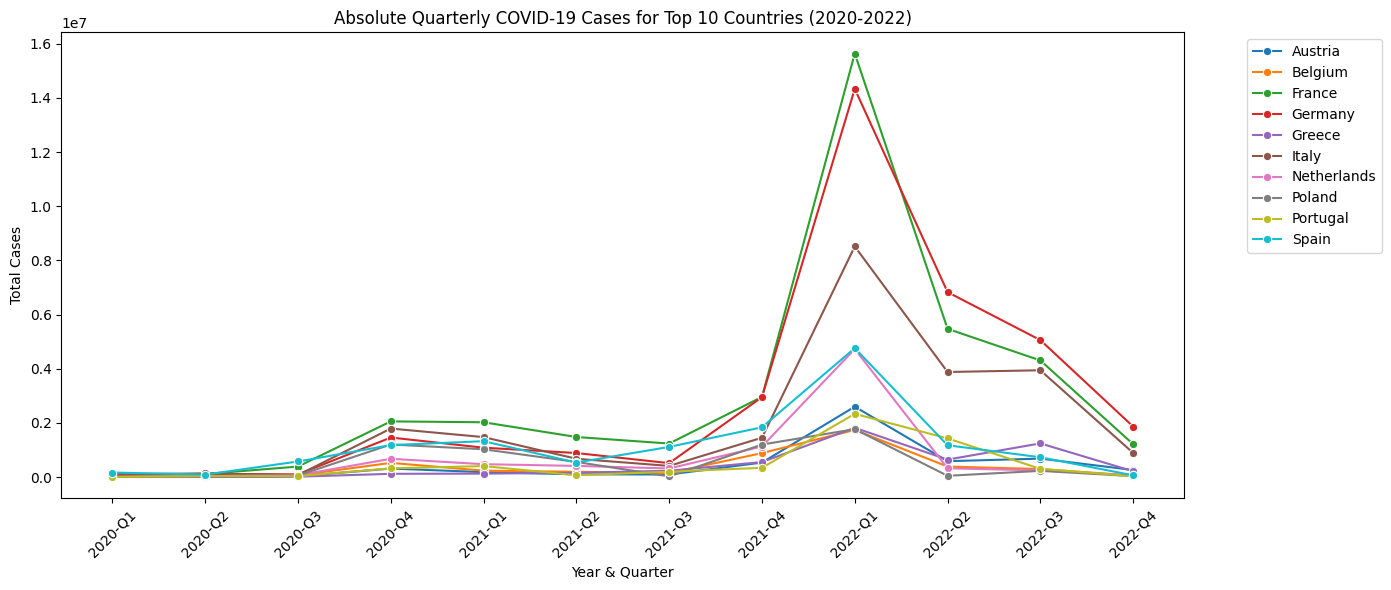

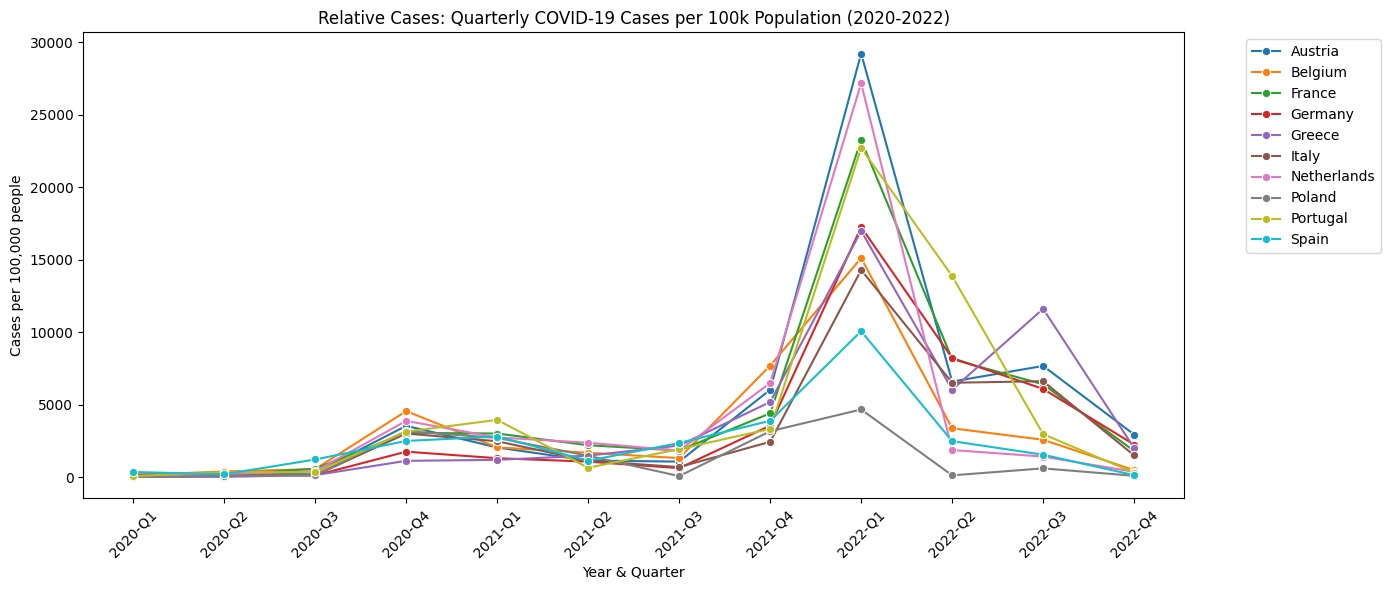

In [89]:


# create year and quarter columns for plotting
df_cases_clean['Year'] = df_cases_clean['dateRep'].dt.year
df_cases_clean['Quarter'] = df_cases_clean['dateRep'].dt.quarter
df_cases_clean['Year_Quarter'] = df_cases_clean['Year'].astype(str) + "-Q" + df_cases_clean['Quarter'].astype(str)

# find top 10 countries with absolute cases
top_10_cases = (
    df_cases_clean.groupby('countriesAndTerritories')['cases']
    .sum()
    .nlargest(10)
 )
top_10_countries = top_10_cases.index.tolist()
print("Top 10 countries with the most absolute number of cases:")
for i, (country, total_cases) in enumerate(top_10_cases.items(), 1):
    print(f"{i}. {country}: {int(total_cases)}")

# filtering to just use top 10
df_top10 = df_cases_clean[df_cases_clean['countriesAndTerritories'].isin(top_10_countries)]

# group data to get sum of cases per quarter
quarterly_cases = df_top10.groupby(['countriesAndTerritories', 'Year_Quarter'])['cases'].sum().reset_index()

# get the population for each country to calculate relative numbers
country_pops = df_top10.groupby('countriesAndTerritories')['popData2020'].max().reset_index()

# merge the population data
quarterly_cases = quarterly_cases.merge(country_pops, on='countriesAndTerritories')

#Calculate Incidence Rate
quarterly_cases['cases_per_100k'] = (quarterly_cases['cases'] / quarterly_cases['popData2020']) * 100000
# grouping bby country 
top10_total = df_top10.groupby('countriesAndTerritories').agg({'cases': 'sum', 'popData2020': 'max'}).reset_index()
top10_total['total_cases_per_100k'] = (top10_total['cases'] / top10_total['popData2020']) * 100000
top10_total = top10_total.sort_values(by='total_cases_per_100k', ascending=False)

print("Top 10 countries based on total cases per 100 000 people (2020-2022):")
for i, (index, row) in enumerate(top10_total.iterrows(), 1):
    print(f"{i}. {row['countriesAndTerritories']}: {int(row['total_cases_per_100k'])}")


# Plot 1: Absolute Cases
plt.figure(figsize=(14, 6))
sns.lineplot(data=quarterly_cases, x='Year_Quarter', y='cases', hue='countriesAndTerritories', marker='o')
plt.title('Absolute Quarterly COVID-19 Cases for Top 10 Countries (2020-2022)')
plt.ylabel('Total Cases')
plt.xlabel('Year & Quarter')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Relative Cases
plt.figure(figsize=(14, 6))
sns.lineplot(data=quarterly_cases, x='Year_Quarter', y='cases_per_100k', hue='countriesAndTerritories', marker='o')
plt.title('Relative Cases: Quarterly COVID-19 Cases per 100k Population (2020-2022)')
plt.ylabel('Cases per 100,000 people')
plt.xlabel('Year & Quarter')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Q2:

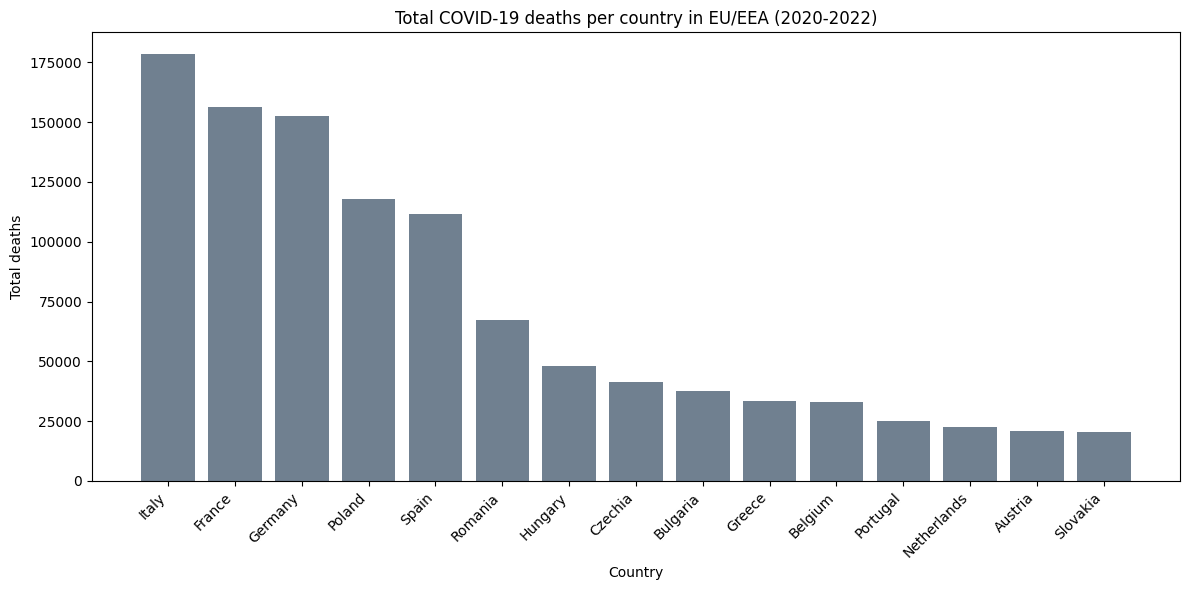

In [90]:
# aggregate data for mapping
map_data = df_cases_clean.groupby(['countriesAndTerritories', 'countryterritoryCode', 'year'])[['cases', 'deaths']].sum().reset_index()

# ¨values to set the color scale for the maps
max_cases = map_data['cases'].max()
max_deaths = map_data['deaths'].max()

# create map for CASES
fig_cases = px.choropleth(
    map_data,
    locations="countryterritoryCode",
    color="cases",
    hover_name="countriesAndTerritories",
    animation_frame="year",
    color_continuous_scale="Reds",
    range_color=[0, max_cases],
    scope="europe",
    title="Total COVID-19 Cases per Country in EU/EEA (2020-2022)"
 )

# create map for DEATHS
fig_deaths = px.choropleth(
    map_data,
    locations="countryterritoryCode",
    color="deaths",
    hover_name="countriesAndTerritories",
    animation_frame="year",
    color_continuous_scale="Greys",
    range_color=[0, max_deaths],
    scope="europe",
    title="Total COVID-19 Deaths per Country in EU/EEA (2020-2022)"
 )
map_data['death_rate_per_100k'] = (map_data['deaths'] / map_data['cases']) * 100000

fig_cases.show()
fig_deaths.show()

# 5. Plot total deaths
total_deaths = (
    map_data.groupby('countriesAndTerritories')['deaths']
    .sum()
    .sort_values(ascending=False)
    .head(15)
 )

plt.figure(figsize=(12, 6))
plt.bar(total_deaths.index.str.replace('_', ' '), total_deaths.values, color='slategray')
plt.title('Total COVID-19 deaths per country in EU/EEA (2020-2022)')
plt.ylabel('Total deaths')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Q3.

Understand the data

In [91]:
# look at the vaccination dataset
print(df_vax.columns)
display(df_vax.head())

Index(['YearWeekISO', 'ReportingCountry', 'Denominator', 'NumberDosesReceived',
       'NumberDosesExported', 'FirstDose', 'FirstDoseRefused', 'SecondDose',
       'DoseAdditional1', 'DoseAdditional2', 'DoseAdditional3',
       'DoseAdditional4', 'DoseAdditional5', 'UnknownDose', 'Region',
       'TargetGroup', 'Vaccine', 'Population'],
      dtype='str')


,YearWeekISO,ReportingCountry,Denominator,NumberDosesReceived,NumberDosesExported,FirstDose,FirstDoseRefused,SecondDose,DoseAdditional1,DoseAdditional2,DoseAdditional3,DoseAdditional4,DoseAdditional5,UnknownDose,Region,TargetGroup,Vaccine,Population
0,2021-W05,AT,423433.0,0.0,0.0,0,NaN,0,0,0,0,0,0,0,AT,Age10_14,AZ,8932664
1,2023-W10,AT,1543886.0,0.0,0.0,0,NaN,1,0,0,0,0,0,0,AT,Age<18,NVXD,8978929
2,2023-W10,AT,1047888.0,0.0,0.0,1,NaN,0,0,1,0,0,0,0,AT,Age60_69,NVXD,8978929
3,2023-W10,AT,258398.0,0.0,0.0,0,NaN,0,0,0,0,0,0,0,AT,Age15_17,MODBA.1,8978929
4,2023-W10,AT,7388778.0,0.0,0.0,3,NaN,1,4,80,53,0,0,0,AT,ALL,MOD,8978929


In [92]:

# define columns that represent administered doses
# Note: 'FirstDoseRefused' is explicitly excluded.
dose_columns = [
    'FirstDose', 'SecondDose', 'DoseAdditional1', 'DoseAdditional2', 
    'DoseAdditional3', 'DoseAdditional4', 'DoseAdditional5', 'UnknownDose'
]

# Fill NaN values with 0
df_vax[dose_columns] = df_vax[dose_columns].fillna(0)

# Calculate total doses
df_vax['TotalDoses'] = df_vax[dose_columns].sum(axis=1)

# Find Top 3 vaccines
eu_top_vaccines = df_vax.groupby('Vaccine')['TotalDoses'].sum().nlargest(3).reset_index()
top_3_eu_list = eu_top_vaccines['Vaccine'].tolist()


print("TOP 3 MOST POPULAR VACCINES ACROSS EU/EEA:")

for i, row in eu_top_vaccines.iterrows():
    print(f"{i+1}. {row['Vaccine']}: {int(row['TotalDoses']):,} doses")

# Check popularity at the country level
country_vax = df_vax.groupby(['ReportingCountry', 'Vaccine'])['TotalDoses'].sum().reset_index()

exceptions = []


print("CHECKING COUNTRY EXCEPTIONS...")


# Loop through each unique country
for country in country_vax['ReportingCountry'].unique():
    # Get data for the specific country
    country_data = country_vax[country_vax['ReportingCountry'] == country]
    
    # Sort by total doses and get the Top 3 vaccines for this country
    country_top_3 = country_data.sort_values(by='TotalDoses', ascending=False).head(3)['Vaccine'].tolist()
    
    # Check if the country's Top 3 matches the EU's Top 3 (ignoring order)
    if set(country_top_3) != set(top_3_eu_list):
        exceptions.append((country, country_top_3))

# Print the results for exceptions
if not exceptions:
    print("All countries share the exact same Top 3 vaccines as the EU/EEA overall.")
else:
    print(f"Found {len(exceptions)} exception(s) where the country's Top 3 differs from the EU average:\n")
    for country, vax_list in exceptions:
        print(f"- {country}'s Top 3: {', '.join(vax_list)}")

TOP 3 MOST POPULAR VACCINES ACROSS EU/EEA:
1. COM: 1,239,822,614 doses
2. UNK: 862,532,787 doses
3. MOD: 296,957,284 doses
CHECKING COUNTRY EXCEPTIONS...
Found 28 exception(s) where the country's Top 3 differs from the EU average:

- AT's Top 3: COM, MOD, AZ
- BE's Top 3: COM, MOD, COMBA.1
- BG's Top 3: COM, JANSS, MOD
- CY's Top 3: COM, AZ, MOD
- CZ's Top 3: COM, MOD, AZ
- DE's Top 3: UNK
- DK's Top 3: COM, MOD, COMBA.4-5
- EE's Top 3: COM, AZ, MOD
- EL's Top 3: COM, MOD, AZ
- ES's Top 3: COM, MOD, AZ
- HR's Top 3: COM, AZ, MOD
- HU's Top 3: COM, BECNBG, SPU
- IE's Top 3: COM, MOD, AZ
- IS's Top 3: COM, AZ, MOD
- IT's Top 3: COM, MOD, AZ
- LI's Top 3: MOD, COM, MODBA.1
- LT's Top 3: COM, AZ, MOD
- LU's Top 3: COM, MOD, AZ
- LV's Top 3: COM, MOD, JANSS
- MT's Top 3: COM, MOD, AZ
- NL's Top 3: COM, MOD, AZ
- NO's Top 3: COM, MOD, COMBA.4-5
- PL's Top 3: COM, AZ, MOD
- PT's Top 3: COM, MOD, AZ
- RO's Top 3: COM, JANSS, MOD
- SE's Top 3: COM, MOD, AZ
- SI's Top 3: COM, AZ, MOD
- SK's Top 

Unlike the overall EU average, none of the individual countries have 'Unknown' (UNK) in their top three, with the sole exception of Germany. Germany only reported 'Unknown' vaccine brands to the ECDC, which heavily skews the total EU data.

Q4:

In [93]:
# filtering out ALL 
df_vax_targets = df_vax[df_vax['TargetGroup'] != 'ALL'].copy()

# Filter the dataset to ONLY include the Top 3 EU vaccines from Question 3
df_top_vaccines = df_vax_targets[df_vax_targets['Vaccine'].isin(top_3_eu_list)]

# Group by Country, Vaccine, and Target Group
target_group_doses = df_top_vaccines.groupby(
    ['ReportingCountry', 'Vaccine', 'TargetGroup']
)['TotalDoses'].sum().reset_index()

# find the Target Group that received the highest number of doses for each combination
main_target_groups = target_group_doses.sort_values(
    by=['ReportingCountry', 'Vaccine', 'TotalDoses'], 
    ascending=[True, True, False]
)
main_target_groups = main_target_groups.drop_duplicates(subset=['ReportingCountry', 'Vaccine'], keep='first')

# Create a Pivot Table
pivot_targets = main_target_groups.pivot(
    index='ReportingCountry', 
    columns='Vaccine', 
    values='TargetGroup'
)
pivot_targets = pivot_targets.fillna("No Data")

print("MAIN TARGET GROUPS FOR THE TOP 3 VACCINES PER COUNTRY:")
display(pivot_targets)

MAIN TARGET GROUPS FOR THE TOP 3 VACCINES PER COUNTRY:


Vaccine,COM,MOD,UNK
ReportingCountry,,,
AT,Age25_49,Age25_49,Age25_49
BE,Age25_49,Age25_49,No Data
BG,Age25_49,Age25_49,No Data
CY,Age25_49,Age25_49,No Data
CZ,Age25_49,Age25_49,No Data
DE,No Data,No Data,1_Age<60
DK,Age25_49,Age25_49,No Data
EE,Age25_49,Age25_49,No Data
EL,1_Age<60,1_Age<60,No Data


Q5:

TOP 5 MOST SKEPTICAL COUNTRIES (FIRST DOSE REFUSED):


,ReportingCountry,FirstDoseRefused
15,IS,581.0
0,AT,0.0
2,BG,0.0
3,CY,0.0
4,CZ,0.0


HOSPITALIZATION LEVELS (TOTAL SUM OF REPORTED VALUES):


,country,value
23,Spain,4.023601e+06
20,Romania,3.408840e+06
6,France,2.841670e+06
4,Czechia,2.118721e+06
1,Belgium,2.023928e+06
0,Austria,1.205130e+06
21,Slovakia,1.126068e+06
2,Bulgaria,4.011940e+05
15,Lithuania,3.929960e+05
22,Slovenia,3.672351e+05


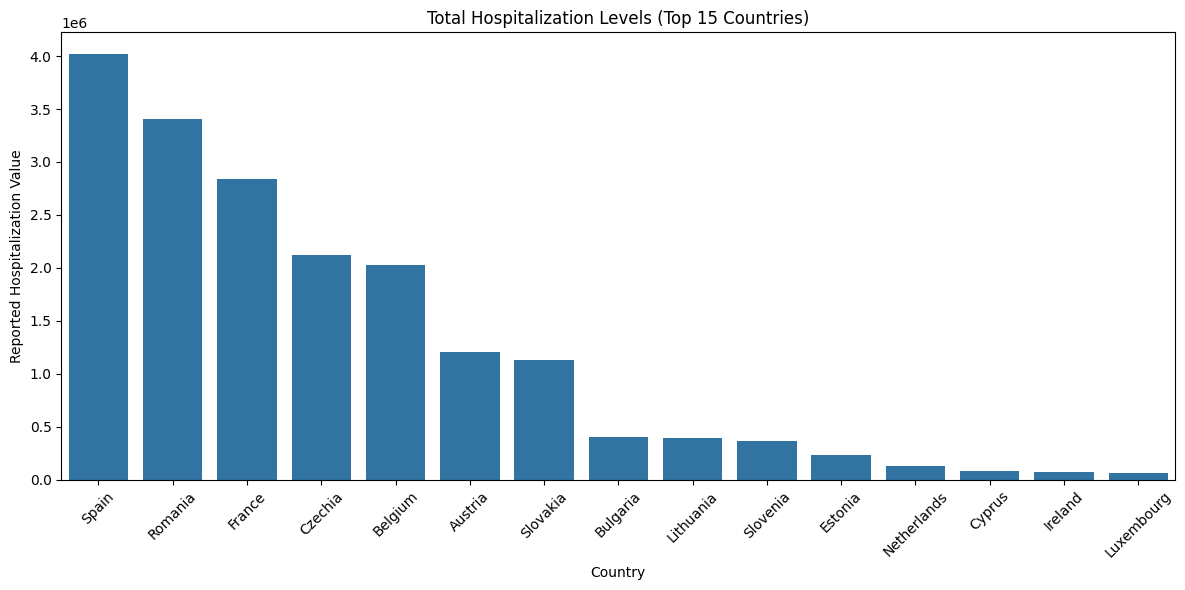

In [94]:

# IDENTIFY THE MOST SKEPTICAL COUNTRIES

# Convert 'FirstDoseRefused' to numeric
df_vax['FirstDoseRefused'] = pd.to_numeric(df_vax['FirstDoseRefused'], errors='coerce').fillna(0)

# Group by country and sum the total number of refused first doses
skepticism_df = df_vax.groupby('ReportingCountry')['FirstDoseRefused'].sum().reset_index()

# Sort to find the countries with the highest number
skepticism_df = skepticism_df.sort_values(by='FirstDoseRefused', ascending=False)


print("TOP 5 MOST SKEPTICAL COUNTRIES (FIRST DOSE REFUSED):")
display(skepticism_df.head(5))



df_hosp_filtered = df_hosp_clean[df_hosp_clean['indicator'].str.contains('hospital', case=False, na=False)]

# group by country
hosp_summary = df_hosp_filtered.groupby('country')['value'].sum().reset_index()
hosp_summary = hosp_summary.sort_values(by='value', ascending=False)


print("HOSPITALIZATION LEVELS (TOTAL SUM OF REPORTED VALUES):")
display(hosp_summary.head(10))

# Visualization: Compare Hospitalization vs Skepticism

plt.figure(figsize=(12, 6))
sns.barplot(data=hosp_summary.head(15), x='country', y='value', legend=False)
plt.title('Total Hospitalization Levels (Top 15 Countries)')
plt.xticks(rotation=45)
plt.ylabel('Reported Hospitalization Value')
plt.xlabel('Country')
plt.tight_layout()
plt.show()

FirstDoseRefused bad column quality, only Iceland recorded this while the rest reported zero

TOP 5 LEAST VACCINATED COUNTRIES (PROXY FOR SKEPTICISM):
1. Bulgaria: 31.4% of the population
2. Slovakia: 52.0% of the population
3. Croatia: 59.5% of the population
4. Slovenia: 59.6% of the population
5. Estonia: 65.3% of the population


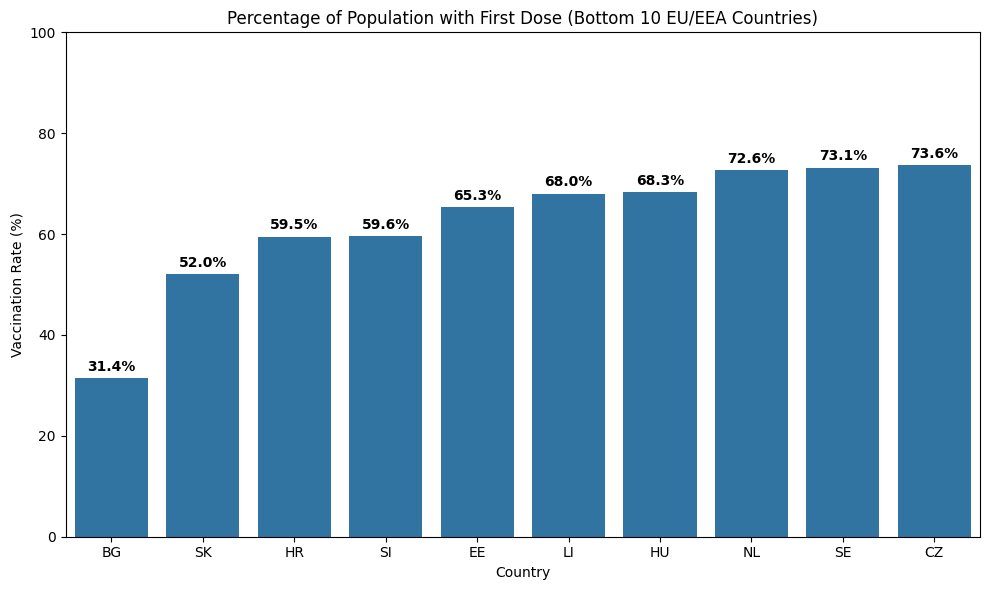

In [95]:
# VACCINATION UPTAKE AS A PROXY FOR SKEPTICISM

df_vax_clean['Population'] = pd.to_numeric(df_vax_clean['Population'], errors='coerce')
df_vax_clean['FirstDose'] = pd.to_numeric(df_vax_clean['FirstDose'], errors='coerce')

#Filter out the 'ALL' target group to avoid double-counting doses
df_vax_filtered = df_vax_clean[df_vax_clean['TargetGroup'] != 'ALL']

# Group by country to get total first doses and the population
vax_summary = df_vax_filtered.groupby('ReportingCountry').agg(
    TotalFirstDoses=('FirstDose', 'sum'),
    CountryPopulation=('Population', 'max') 
).reset_index()

# Calculate the percentage
vax_summary['Vaccinated_Percentage'] = (vax_summary['TotalFirstDoses'] / vax_summary['CountryPopulation']) * 100

# lowest rate to highest
vax_summary = vax_summary.sort_values(by='Vaccinated_Percentage', ascending=True).dropna()

# full country names 
vax_summary['FullCountryName'] = vax_summary['ReportingCountry'].map(country_names)

# Print the table for the 5 least vaccinated countries

print("TOP 5 LEAST VACCINATED COUNTRIES (PROXY FOR SKEPTICISM):")

for rank, row in enumerate(vax_summary.head(5).itertuples(), start=1):
    print(f"{rank}. {row.FullCountryName}: {row.Vaccinated_Percentage:.1f}% of the population")


# bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=vax_summary.head(10), 
    x='ReportingCountry', 
    y='Vaccinated_Percentage',
    legend=False
)

plt.title('Percentage of Population with First Dose (Bottom 10 EU/EEA Countries)')
plt.ylabel('Vaccination Rate (%)')
plt.xlabel('Country')
plt.ylim(0, 100)

# add precentege for clarity
for index, value in enumerate(vax_summary.head(10)['Vaccinated_Percentage']):
    plt.text(index, value + 1.5, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Bulgaria low vaccination rate and relatively high hospilitazion rate. Same with Slovakia. For such small countries compared to the others which is big. 

Q6:

MOST VACCINATED UNDER-18 POPULATION (Top 5 Countries):


,ReportingCountry,U18_FirstDoses,TotalPopulation,U18_Vax_Percentage,FullCountryName
9,IS,43091,376248,11.452818,Iceland
5,ES,4859297,47432893,10.244572,Spain
16,PT,1003285,10352042,9.691663,Portugal
6,FI,453284,5548241,8.169869,Finland
3,DK,473881,5873420,8.068229,Denmark


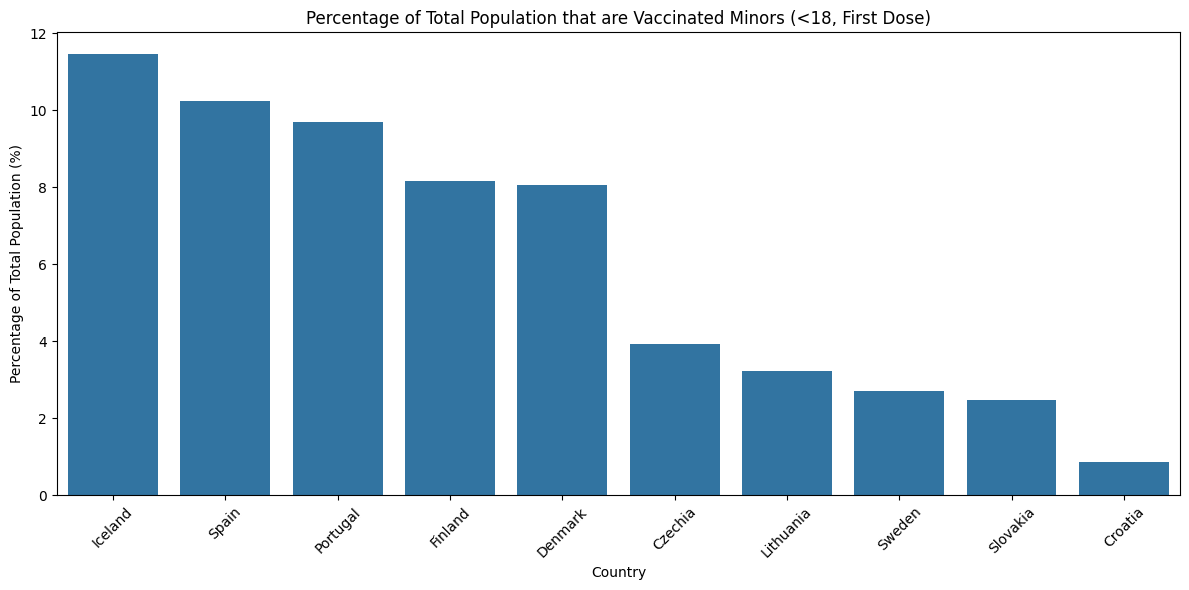

In [96]:
df_vax_national = df_vax_clean[df_vax_clean['Region'] == df_vax_clean['ReportingCountry']].copy()

# define the groups
granular_groups = ['Age0_4', 'Age5_9', 'Age10_14', 'Age15_17']

# create a dataframe
df_granular = df_vax_national[df_vax_national['TargetGroup'].isin(granular_groups)].copy()
df_granular['FirstDose'] = pd.to_numeric(df_granular['FirstDose'], errors='coerce').fillna(0)
df_granular['Population'] = pd.to_numeric(df_granular['Population'], errors='coerce')

# sums the doses for the granular groups
u18_granular_sum = df_granular.groupby('ReportingCountry').agg(
    U18_FirstDoses=('FirstDose', 'sum'),
    TotalPopulation=('Population', 'max')
).reset_index()

# check for missing data in the granular summary
missing_countries = u18_granular_sum[u18_granular_sum['U18_FirstDoses'] == 0]['ReportingCountry'].tolist()

# if we have m,issinng data then add them with their 'Age<18' or 'Age5_14' data
df_broad = df_vax_national[
    (df_vax_national['ReportingCountry'].isin(missing_countries)) & 
    (df_vax_national['TargetGroup'].isin(['Age<18', 'Age5_14'])) 
].copy()

df_broad['FirstDose'] = pd.to_numeric(df_broad['FirstDose'], errors='coerce').fillna(0)
df_broad['Population'] = pd.to_numeric(df_broad['Population'], errors='coerce')

u18_broad_sum = df_broad.groupby('ReportingCountry').agg(
    U18_FirstDoses=('FirstDose', 'sum'),
    TotalPopulation=('Population', 'max')
).reset_index()

# add the broad summary to the granular summary
u18_summary = pd.concat([
    u18_granular_sum[u18_granular_sum['U18_FirstDoses'] > 0], 
    u18_broad_sum
])

# calculate percentage
u18_summary['U18_Vax_Percentage'] = (u18_summary['U18_FirstDoses'] / u18_summary['TotalPopulation']) * 100
u18_summary['FullCountryName'] = u18_summary['ReportingCountry'].map(country_names)

# sort
u18_sorted = u18_summary.sort_values(by='U18_Vax_Percentage', ascending=False).dropna()


print("MOST VACCINATED UNDER-18 POPULATION (Top 5 Countries):")
display(u18_sorted.head(5))

#  visualizing the top and bottom 5
top_bottom_10 = pd.concat([u18_sorted.head(5), u18_sorted.tail(5)])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_bottom_10,
    x='FullCountryName',
    y='U18_Vax_Percentage',
    legend=False
)

plt.title('Percentage of Total Population that are Vaccinated Minors (<18, First Dose)')
plt.ylabel('Percentage of Total Population (%)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Q7:

COUNTRIES WITH THE OLDEST VACCINATED POPULATION (SECOND DOSE):


,ReportingCountry,Senior_SecondDoses,TotalPopulation,Senior_Vax_Percentage,FullCountryName
9,FI,1539025,5548241,27.738972,Finland
24,PT,2850385,10352042,27.534519,Portugal
15,IT,16207428,59641488,27.174755,Italy
5,DK,1523615,5873420,25.940849,Denmark
7,EL,2696484,10718565,25.157136,Greece
1,BE,2840014,11617623,24.445741,Belgium
8,ES,11572556,47432893,24.397744,Spain
10,FR,16532224,67871925,24.357971,France
20,MT,124544,520971,23.906129,Malta
26,SE,2458642,10452326,23.522439,Sweden


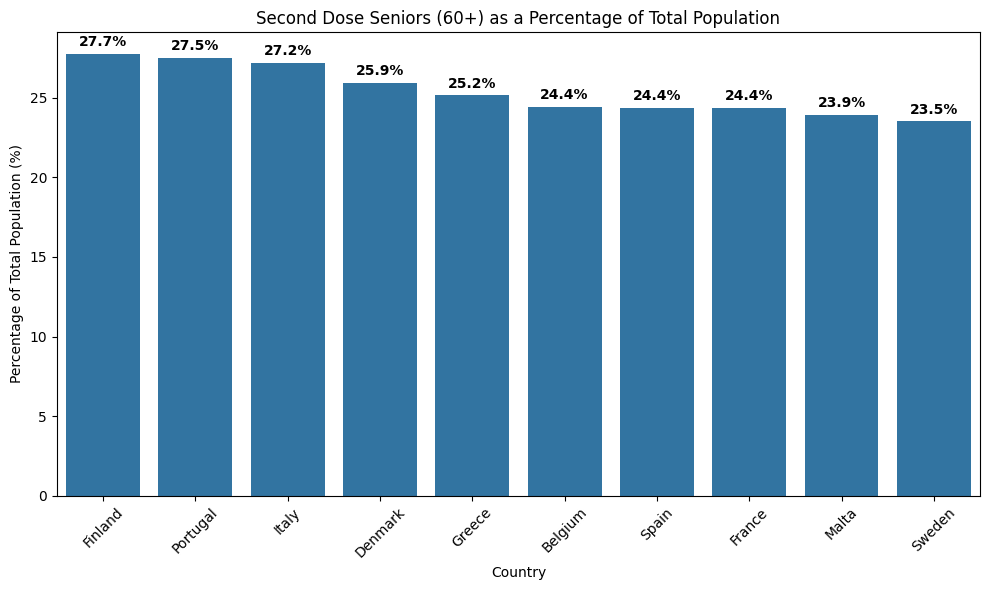

In [97]:

#
df_vax_national = df_vax_clean[df_vax_clean['Region'] == df_vax_clean['ReportingCountry']].copy()

# define age groups 
granular_seniors = ['Age60_69', 'Age70_79', 'Age80+']
broad_seniors = ['1_Age60+']

# load the granular data for seniors
df_seniors_granular = df_vax_national[df_vax_national['TargetGroup'].isin(granular_seniors)].copy()
df_seniors_granular['SecondDose'] = pd.to_numeric(df_seniors_granular['SecondDose'], errors='coerce').fillna(0)
df_seniors_granular['Population'] = pd.to_numeric(df_seniors_granular['Population'], errors='coerce')

senior_granular_sum = df_seniors_granular.groupby('ReportingCountry').agg(
    Senior_SecondDoses=('SecondDose', 'sum'),
    TotalPopulation=('Population', 'max') 
).reset_index()

# ifnd the countries that are missing data
missing_senior_countries = senior_granular_sum[senior_granular_sum['Senior_SecondDoses'] == 0]['ReportingCountry'].tolist()

# load data for the "missing" countries
df_seniors_broad = df_vax_national[
    (df_vax_national['ReportingCountry'].isin(missing_senior_countries)) &
    (df_vax_national['TargetGroup'].isin(broad_seniors))
].copy()

df_seniors_broad['SecondDose'] = pd.to_numeric(df_seniors_broad['SecondDose'], errors='coerce').fillna(0)
df_seniors_broad['Population'] = pd.to_numeric(df_seniors_broad['Population'], errors='coerce')

senior_broad_sum = df_seniors_broad.groupby('ReportingCountry').agg(
    Senior_SecondDoses=('SecondDose', 'sum'),
    TotalPopulation=('Population', 'max')
).reset_index()

# merge the data
senior_summary = pd.concat([
    senior_granular_sum[senior_granular_sum['Senior_SecondDoses'] > 0],
    senior_broad_sum
])

# calculate the percentage of seniors with second dose
senior_summary['Senior_Vax_Percentage'] = (senior_summary['Senior_SecondDoses'] / senior_summary['TotalPopulation']) * 100
senior_summary['FullCountryName'] = senior_summary['ReportingCountry'].map(country_names)

senior_sorted = senior_summary.sort_values(by='Senior_Vax_Percentage', ascending=False).dropna()


print("COUNTRIES WITH THE OLDEST VACCINATED POPULATION (SECOND DOSE):")
display(senior_sorted.head(10))

# create vizualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=senior_sorted.head(10), 
    x='FullCountryName', 
    y='Senior_Vax_Percentage',
    legend=False
)

plt.title('Second Dose Seniors (60+) as a Percentage of Total Population')
plt.ylabel('Percentage of Total Population (%)')
plt.xlabel('Country')
plt.xticks(rotation=45)

# add percentage labels on top of the bars for clarity
for index, value in enumerate(senior_sorted.head(10)['Senior_Vax_Percentage']):
    plt.text(index, value + 0.5, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Q8:

MOST AFFECTED HEALTHCARE SYSTEMS IN 2020 (reported hospital/ICU cases):
1. Spain: 1,172,059
2. France: 692,267
3. Belgium: 644,356
4. Czechia: 520,127
5. Austria: 250,307
6. Slovakia: 148,559
7. Slovenia: 95,066
8. Lithuania: 69,786
9. Bulgaria: 69,119
10. Netherlands: 42,507
MOST AFFECTED HEALTHCARE SYSTEMS IN 2022 (reported hospital/ICU cases):
1. France: 1,069,182 
2. Romania: 1,043,189 
3. Spain: 705,357 
4. Belgium: 648,908 
5. Austria: 493,076 
6. Czechia: 430,600 
7. Slovakia: 346,101 
8. Estonia: 84,674 
9. Bulgaria: 81,218 
10. Slovenia: 80,680 


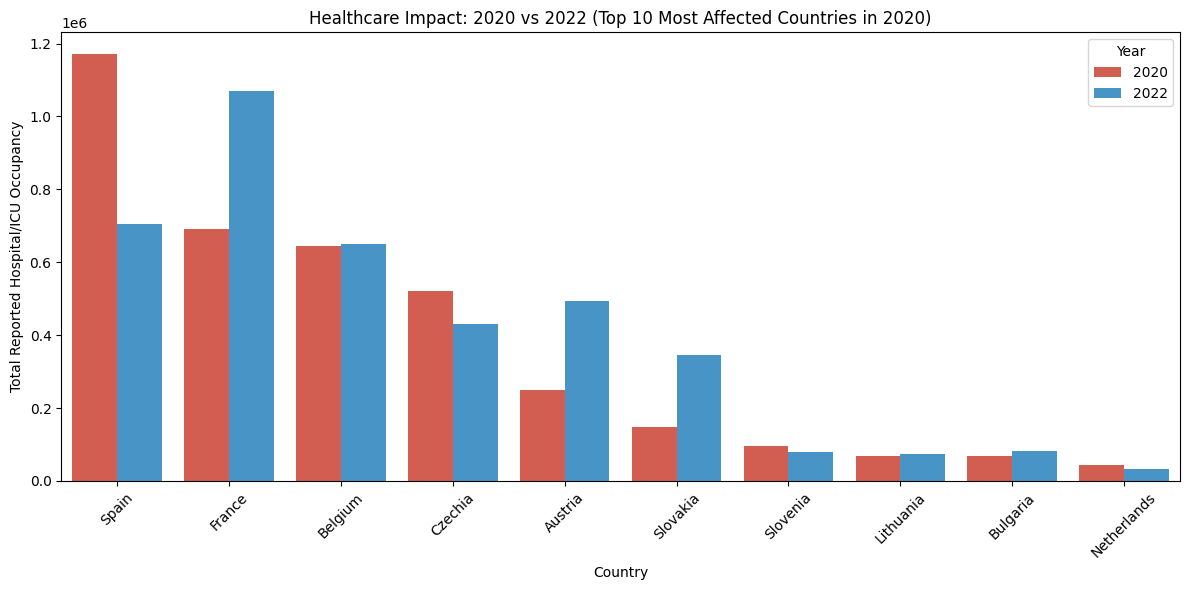

In [98]:

# Ensure 'value' is numeric
df_hosp_clean['value'] = pd.to_numeric(df_hosp_clean['value'], errors='coerce').fillna(0)

# Extract the year from the date or year_week column
if 'year_week' in df_hosp_clean.columns:
    df_hosp_clean['year'] = df_hosp_clean['year_week'].astype(str).str[:4]
elif 'date' in df_hosp_clean.columns:
    df_hosp_clean['year'] = df_hosp_clean['date'].astype(str).str[:4]
else:
    print("Could not find a date column!")

#Filter the data for 2020 and 2022
df_2020 = df_hosp_clean[df_hosp_clean['year'] == '2020']
df_2022 = df_hosp_clean[df_hosp_clean['year'] == '2022']

# Group by country and sum the values to get the total healthcare burden
hosp_2020 = df_2020.groupby('country')['value'].sum().reset_index().sort_values(by='value', ascending=False)
hosp_2022 = df_2022.groupby('country')['value'].sum().reset_index().sort_values(by='value', ascending=False)

# Print the Top 10

print("MOST AFFECTED HEALTHCARE SYSTEMS IN 2020 (reported hospital/ICU cases):")
for rank, row in enumerate(hosp_2020.head(10).itertuples(), start=1):
    print(f"{rank}. {row.country}: {int(row.value):,}")

print("MOST AFFECTED HEALTHCARE SYSTEMS IN 2022 (reported hospital/ICU cases):")
for rank, row in enumerate(hosp_2022.head(10).itertuples(), start=1):
    print(f"{rank}. {row.country}: {int(row.value):,} ")

#  Visualization:
top_countries_2020 = hosp_2020.head(10)['country'].tolist()

# Filter both years to only include these specific countries
compare_2020 = hosp_2020[hosp_2020['country'].isin(top_countries_2020)].copy()
compare_2020['Year'] = '2020'

compare_2022 = hosp_2022[hosp_2022['country'].isin(top_countries_2020)].copy()
compare_2022['Year'] = '2022'

# Combine the datasets for the plot
df_compare = pd.concat([compare_2020, compare_2022])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_compare, 
    x='country', 
    y='value', 
    hue='Year',
    palette=['#e74c3c', '#3498db'] # Red for 2020, Blue for 2022
)

plt.title('Healthcare Impact: 2020 vs 2022 (Top 10 Most Affected Countries in 2020)')
plt.ylabel('Total Reported Hospital/ICU Occupancy')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()